# Import Libraries

In [1]:
import numpy as np
import pandas as pd
import random
import math

import tensorflow as tf
import tensorflow_datasets as tfds
from keras.preprocessing.text import Tokenizer


from sklearn.preprocessing import LabelEncoder
from sklearn import ensemble
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.cluster import MiniBatchKMeans
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA


import matplotlib.pyplot as plt
import seaborn as sns

import os
import shutil
import pathlib
from tqdm import tqdm
import re

import warnings
warnings.filterwarnings("ignore", category=UserWarning) #used to supress the tf version warning.

In [2]:
# Code to read csv file into Colaboratory:
#!pip install -U -q PyDrive
from pydrive.auth import GoogleAuth
from pydrive.drive import GoogleDrive
from google.colab import auth
from oauth2client.client import GoogleCredentials
# Authenticate and create the PyDrive client.
auth.authenticate_user()
gauth = GoogleAuth()
gauth.credentials = GoogleCredentials.get_application_default()
drive = GoogleDrive(gauth)

# Data Loading and Preprocessing

### Load Data from Shareable Link

In [3]:
def create_df_from_shareable_link(shareable_link):
  id = shareable_link.split('/d/')[1].split('/')[0]
  downloaded = drive.CreateFile({'id':id})
  downloaded.GetContentFile('Filename.csv')
  df_temp = pd.read_csv('Filename.csv')
  return df_temp

In [4]:
figshare_link = 'https://drive.google.com/file/d/1mJaIaklZ6KLbIU9vFj5Z7Lwv3TUxPoRc/view?usp=drive_link'
kaggle_link = 'https://drive.google.com/file/d/1mRoZaJRWgx8MVvZW963XD7jbAOWn1i21/view?usp=drive_link'

figshare_df = create_df_from_shareable_link(figshare_link)
kaggle_df = create_df_from_shareable_link(kaggle_link)

Confirm data was loaded correctly

In [5]:
print(figshare_df.shape)
print(kaggle_df.shape)

(91608, 71)
(49950, 13)


In [6]:
# Kaggle: defining high quality vs. low quality articles

kaggle_df['Quality'] = [1.0 if score >= 70.00 else 0.0 for score in kaggle_df['wikirank_quality']]

Further feature engineering: Creating a new column on the main categories

In [7]:
cur_cats = list(figshare_df['categories'].value_counts().index)
sub_cats = list(set([i.split('.')[1] for i in cur_cats]))
top_cats = list(set([i.split('.')[0] for i in cur_cats]))
print("Low Level Categories")
print(cur_cats)
print(len(cur_cats))
print('\n')
print("Sub Level Categories")
print(sub_cats)
print(len(sub_cats))
print('\n')
print("Top Level Categories")
print(top_cats)
print(len(top_cats))

Low Level Categories
['Culture.Biography.Biography*', 'Culture.Sports', 'STEM.Biology', 'Geography.Regions.Americas.North_America', 'Culture.Media.Media*', 'STEM.STEM*', 'Geography.Regions.Europe.Europe*', 'Geography.Regions.Asia.Asia*', 'Culture.Media.Music', 'Geography.Regions.Europe.Northern_Europe', 'Geography.Regions.Oceania', 'History_and_Society.Transportation', 'Geography.Regions.Asia.South_Asia', 'Geography.Regions.Europe.Eastern_Europe', 'Culture.Linguistics', 'History_and_Society.Military_and_warfare', 'History_and_Society.Politics_and_government', 'Culture.Media.Films', 'Culture.Visual_arts.Architecture', 'Culture.Literature', 'Geography.Regions.Europe.Western_Europe', 'Geography.Regions.Asia.East_Asia', 'Geography.Regions.Europe.Southern_Europe', 'Culture.Philosophy_and_religion', 'Geography.Regions.Asia.West_Asia', 'History_and_Society.Business_and_economics', 'Geography.Regions.Americas.South_America', 'Geography.Regions.Africa.Africa*', 'Culture.Media.Television', 'Geog

In [8]:
main_categories = []

for row in figshare_df['categories']:
    main_categories.append(row.split('.')[0])

figshare_df['main_categories'] = main_categories
figshare_df['main_categories_nums'] = figshare_df['main_categories'].replace({
    'STEM':0, 'History_and_Society':1, 'Culture':2, 'Geography':3
})

### Split into Train, Val, and Test

In [9]:
X_train = figshare_df[['intro_text','url', 'main_categories', 'categories']].astype(str)

In [10]:
print("X_train.shape:", X_train.shape)

X_train.shape: (91608, 4)


In [11]:
# Split Kaggle set into training & testing

X = kaggle_df['intro_text']
y = kaggle_df['Quality']

Kag_X_train, Kag_X_test, Kag_Y_train, Kag_Y_test = train_test_split(X,y,
                                   random_state=104,
                                   test_size=0.25,
                                   shuffle=True)

In [12]:
print("Kaggle X_train shape: ", Kag_X_train.shape)

Kaggle X_train shape:  (37462,)


### Removing non-English and unconventional texts

In [13]:
def text_cleaner(df, column):
    desired_text = r'[^a-zA-Z0-9\s.,!?;:]+'

    # Define a helper function to apply the regex substitution
    def clean_text(text):
        if isinstance(text, str):  # Check if text is a string
            return re.sub(desired_text, '', text)
        else:
            return text  # Return unchanged if not a string

    df[column] = df[column].apply(clean_text)
    return df

# Call the function
X_train = text_cleaner(X_train, 'intro_text')

### Tokenize and create word index

In [14]:
tokenizer = Tokenizer()
figshare_df['intro_text'] = figshare_df['intro_text'].astype(str)
tokenizer.fit_on_texts(figshare_df['intro_text'])
word_index = tokenizer.word_index

kaggle_df['intro_text'] = kaggle_df['intro_text'].astype(str)
tokenizer.fit_on_texts(kaggle_df['intro_text'])
word_index_2 = tokenizer.word_index

X_train['intro_text_tokenized'] = tokenizer.texts_to_sequences(X_train['intro_text'])
Kag_X_train = Kag_X_train.astype(str)
Kag_X_train = tokenizer.texts_to_sequences(Kag_X_train)
Kag_X_test = Kag_X_test.astype(str)
Kag_X_test = tokenizer.texts_to_sequences(Kag_X_test)

In [15]:
print(X_train['intro_text_tokenized'][:1])

0    [1280, 211, 790, 34834, 23, 161, 10692, 215, 1...
Name: intro_text_tokenized, dtype: object


In [16]:
print(Kag_X_train[:1])

[[444916, 1797, 737, 6, 1, 10404, 1797, 93, 1, 809, 2, 2352, 4, 6615, 3, 230, 169, 28496, 981, 506, 228645, 54034, 2557, 5, 2543, 6, 23790, 25549, 16, 14460, 1310, 506, 23779, 8168, 2557, 21, 639, 2543, 6, 6965, 3, 285, 19, 3, 304, 1310, 506, 7271, 60848, 426, 92, 5862, 3, 23790, 25549, 2352, 4, 6615, 19510, 3, 419, 6738, 3, 230, 1, 51, 809, 2747, 6, 407, 5, 1773, 885, 13, 10404, 4005, 93, 53, 981, 10795, 16, 3, 290, 59, 426, 5, 8579, 20161, 1952, 13, 4032, 10397, 8428, 23, 6615, 3907, 997, 3, 9713, 2721, 18, 2352, 6, 2184, 42, 740, 2164, 25, 3, 285, 1, 51, 809, 426, 21, 1952, 6, 2581, 5, 1773, 885, 6, 6395, 48, 662, 2, 4005, 4, 9592, 1, 2120, 98419, 3, 419, 6738, 32, 47, 3, 285, 21, 1952, 7, 426, 93, 2352, 4, 6615, 11, 1118, 4005, 47, 2352, 3168, 219, 533, 368, 7426, 13, 766, 3684, 3, 6615, 9, 9066, 6816, 2352, 8, 3002, 3, 5, 219, 533, 3109, 9077, 1952, 15, 6615, 2352, 1514, 9637, 6, 14460, 508, 6, 2352, 2235, 58, 1, 51, 809, 5654, 2505, 1855, 341, 16, 3, 285, 2352, 4, 6615, 426, 21, 

Average text length can be an indicator for optimal embedding dimension size

In [17]:
print("Average Text Length:", X_train['intro_text_tokenized'].apply(len).mean())
print("Maximum Text Length:", X_train['intro_text_tokenized'].apply(len).max())
print("Minimum Text Length:", X_train['intro_text_tokenized'].apply(len).min())

Average Text Length: 151.3307789712689
Maximum Text Length: 381
Minimum Text Length: 1


In [18]:
word_index

{'the': 1,
 'of': 2,
 'in': 3,
 'and': 4,
 'a': 5,
 'to': 6,
 'was': 7,
 'is': 8,
 'by': 9,
 'as': 10,
 'he': 11,
 'on': 12,
 'for': 13,
 'it': 14,
 'with': 15,
 '1': 16,
 'at': 17,
 'from': 18,
 '2': 19,
 'his': 20,
 'an': 21,
 'this': 22,
 '3': 23,
 'that': 24,
 'article': 25,
 '4': 26,
 'can': 27,
 'which': 28,
 'first': 29,
 'are': 30,
 'were': 31,
 'also': 32,
 '5': 33,
 'you': 34,
 'has': 35,
 'help': 36,
 'wikipedia': 37,
 'expanding': 38,
 'stub': 39,
 'or': 40,
 'she': 41,
 'its': 42,
 'after': 43,
 'one': 44,
 'who': 45,
 'born': 46,
 '6': 47,
 'new': 48,
 'had': 49,
 'her': 50,
 'two': 51,
 'be': 52,
 'their': 53,
 'but': 54,
 'about': 55,
 'school': 56,
 '7': 57,
 'university': 58,
 'during': 59,
 'they': 60,
 'been': 61,
 'national': 62,
 'american': 63,
 'united': 64,
 '8': 65,
 'not': 66,
 'known': 67,
 'all': 68,
 'have': 69,
 'when': 70,
 'time': 71,
 'other': 72,
 'may': 73,
 'team': 74,
 'year': 75,
 'state': 76,
 'where': 77,
 'season': 78,
 'film': 79,
 'years': 80

In [19]:
word_index_2

{'the': 1,
 'of': 2,
 'in': 3,
 'and': 4,
 'a': 5,
 'to': 6,
 'was': 7,
 'is': 8,
 'by': 9,
 'as': 10,
 'on': 11,
 'he': 12,
 'for': 13,
 'it': 14,
 'with': 15,
 '1': 16,
 'at': 17,
 'from': 18,
 '2': 19,
 'his': 20,
 'an': 21,
 'this': 22,
 '3': 23,
 'that': 24,
 '4': 25,
 'article': 26,
 'can': 27,
 'which': 28,
 'first': 29,
 'are': 30,
 'were': 31,
 '5': 32,
 'also': 33,
 'you': 34,
 'help': 35,
 'has': 36,
 'wikipedia': 37,
 'expanding': 38,
 'stub': 39,
 'she': 40,
 'or': 41,
 'its': 42,
 'after': 43,
 'one': 44,
 'who': 45,
 'born': 46,
 '6': 47,
 'new': 48,
 'her': 49,
 'had': 50,
 'two': 51,
 'be': 52,
 'their': 53,
 '7': 54,
 'about': 55,
 'school': 56,
 'but': 57,
 'university': 58,
 'they': 59,
 'during': 60,
 'been': 61,
 'national': 62,
 'american': 63,
 '8': 64,
 'known': 65,
 'united': 66,
 'have': 67,
 'not': 68,
 'all': 69,
 'when': 70,
 'time': 71,
 'may': 72,
 'other': 73,
 'state': 74,
 'where': 75,
 'team': 76,
 'year': 77,
 'season': 78,
 'film': 79,
 'years': 80

In [20]:
index = dict([(key, value+3) for (key, value) in word_index.items()])

# Create a reverse index so we can lookup tokens assigned to each id.
reverse_index = dict([(value, key) for (key, value) in index.items()])
reverse_index[1] = '<START>'  # start of input
reverse_index[2] = '#'        # out-of-vocabulary (OOV)
reverse_index[3] = '<UNUSED>'

max_id = max(reverse_index.keys())
print('Largest ID:', max_id)

Largest ID: 400000


In [21]:
index_kag = dict([(key, value+3) for (key, value) in word_index_2.items()])

# Create a reverse index so we can lookup tokens assigned to each id.
reverse_index_2 = dict([(value, key) for (key, value) in index_kag.items()])
reverse_index_2[1] = '<START>'  # start of input
reverse_index_2[2] = '#'        # out-of-vocabulary (OOV)
reverse_index_2[3] = '<UNUSED>'

max_id_2 = max(reverse_index_2.keys())
print('Largest ID:', max_id_2)

Largest ID: 545905


Decode

In [22]:
def decode(token_ids):
  # Try looking up each id in the index, but return '#' (for OOV) if not found.
  tokens = [reverse_index.get(i, "#") for i in token_ids]
  # Connect the string tokens with a space.
  return ' '.join(tokens)

# Show the ids corresponding tokens in the first example.
print(X_train['intro_text_tokenized'][0])
print(decode(X_train['intro_text_tokenized'][0]))

[1280, 211, 790, 34834, 23, 161, 10692, 215, 152, 4850, 7, 5, 194, 321, 719, 850, 106, 36, 904, 1, 221, 468, 10, 1, 5667, 2, 1, 34834, 2471, 790, 34834, 7, 46, 17, 7756, 3471, 3, 8765, 327, 1, 2856, 911, 2, 59231, 34834, 4, 20, 516, 11810, 16, 3, 8731, 126, 5, 1280, 3, 1, 406, 2497, 12, 28509, 15, 20, 427, 2164, 21, 8029, 2, 537, 12, 195, 11671, 869, 8490, 5, 8491, 35880, 3576, 15, 724, 1487, 24, 13876, 3, 119870, 12, 2657, 6596, 22, 3, 9086, 17, 7025, 19, 12, 1747, 1, 3639, 10, 21, 372692, 5418, 3, 6969, 1, 194, 321, 1741, 5, 702, 57, 8465, 10366, 2471, 28, 1923, 1078, 1, 27351, 106, 23, 14, 36, 13990, 1, 533, 34834, 6, 20987, 18, 2497, 9000, 4, 20987, 3, 211, 1051, 132, 219, 43, 14, 7, 857, 9, 119, 10366, 3421, 117, 1, 260, 2, 82, 122, 141, 1, 9000, 31, 494, 3723, 346, 6, 20, 383, 4313, 34834, 133, 3, 8275, 75, 12, 7, 3806, 3, 7253, 12, 7, 977, 6, 274, 11, 16, 181, 6969, 43, 608, 80, 10, 5, 938, 43, 20, 17586, 960, 3, 670, 17, 1135, 76727, 11, 295, 173, 7569, 25, 34834, 7, 977, 6, 12

In [23]:
def decode_kag(token_ids):
  # Try looking up each id in the index, but return '#' (for OOV) if not found.
  tokens = [reverse_index_2.get(i, "#") for i in token_ids]
  # Connect the string tokens with a space.
  return ' '.join(tokens)

# Show the ids corresponding tokens in the first example.
print(Kag_X_train[0])
print(decode(Kag_X_train[0]))

print(Kag_X_test[0])
print(decode(Kag_X_test[0]))

[444916, 1797, 737, 6, 1, 10404, 1797, 93, 1, 809, 2, 2352, 4, 6615, 3, 230, 169, 28496, 981, 506, 228645, 54034, 2557, 5, 2543, 6, 23790, 25549, 16, 14460, 1310, 506, 23779, 8168, 2557, 21, 639, 2543, 6, 6965, 3, 285, 19, 3, 304, 1310, 506, 7271, 60848, 426, 92, 5862, 3, 23790, 25549, 2352, 4, 6615, 19510, 3, 419, 6738, 3, 230, 1, 51, 809, 2747, 6, 407, 5, 1773, 885, 13, 10404, 4005, 93, 53, 981, 10795, 16, 3, 290, 59, 426, 5, 8579, 20161, 1952, 13, 4032, 10397, 8428, 23, 6615, 3907, 997, 3, 9713, 2721, 18, 2352, 6, 2184, 42, 740, 2164, 25, 3, 285, 1, 51, 809, 426, 21, 1952, 6, 2581, 5, 1773, 885, 6, 6395, 48, 662, 2, 4005, 4, 9592, 1, 2120, 98419, 3, 419, 6738, 32, 47, 3, 285, 21, 1952, 7, 426, 93, 2352, 4, 6615, 11, 1118, 4005, 47, 2352, 3168, 219, 533, 368, 7426, 13, 766, 3684, 3, 6615, 9, 9066, 6816, 2352, 8, 3002, 3, 5, 219, 533, 3109, 9077, 1952, 15, 6615, 2352, 1514, 9637, 6, 14460, 508, 6, 2352, 2235, 58, 1, 51, 809, 5654, 2505, 1855, 341, 16, 3, 285, 2352, 4, 6615, 426, 21, 4

Padding

In [24]:
def pad_data(sequences, max_length):

  return np.array(list(
      tf.keras.preprocessing.sequence.pad_sequences(
          sequences, maxlen=max_length, padding='post', value=0)))

# Pad and truncate to 300 tokens.
X_train_padded = pad_data(X_train['intro_text_tokenized'], max_length=150)

# Check the padded output.
print('Length of X_train[0]:', len(X_train['intro_text_tokenized'][0]))
print('Length of X_train_padded[0]:', len(X_train_padded[0]))
print(X_train_padded[0])


Length of X_train[0]: 288
Length of X_train_padded[0]: 150
[   219     43     14      7    857      9    119  10366   3421    117
      1    260      2     82    122    141      1   9000     31    494
   3723    346      6     20    383   4313  34834    133      3   8275
     75     12      7   3806      3   7253     12      7    977      6
    274     11     16    181   6969     43    608     80     10      5
    938     43     20  17586    960      3    670     17   1135  76727
     11    295    173   7569     25  34834      7    977      6   1280
   2108     11    226    157   7569    974    187    863    846     94
      3   6036      1    194    220   1486 536886   4685      9  15617
    166     16    866   2969      6   3524  18127      3    491      5
     77     13    298     32  26741    232   7699    166     18   1981
      1    530   4391      2     22    329     16     12      7    403
      6      1    381      2    406   2497     11     47    152   6149
     12   1674    

In [25]:
print(decode(X_train_padded[0]))

13 or he and stadium to fetch upazila 82 error <START> along # film ﻿ since <START> wolves which james testing record in at california manuel harmonics area <UNUSED> luther other by and expert <UNUSED> costume by and feature in song is for work equestrian or capital where was of ran or at dagger becoming <UNUSED> assembly it hit миколайович is 17 october jules this harmonics and feature in terms leaders is u group jules 19th several beginning lies district <UNUSED> consistent <START> population each hong # rounded to flip music for structure objects in measures musa <UNUSED> become of team as life first hajj professional years' music with learning <START> services mystery # 2 ii for by and radio in <START> southern # signed boundary is one released ladies by heavy in <START> initial # terms church is – km tourist one harmonics prior it yeshurun town 2008 yeshurun


In [26]:
Kag_X_train_padded = pad_data(Kag_X_train, max_length=150)

print('Length of Kag_X_train[0]:', len(Kag_X_train[0]))
print('Length of Kag_X_train_padded[0]:', len(Kag_X_train_padded[0]))
print(Kag_X_train_padded[0])

Kag_X_test_padded = pad_data(Kag_X_test, max_length=150)

print('Length of Kag_X_test[0]:', len(Kag_X_test[0]))
print('Length of Kag_X_test_padded[0]:', len(Kag_X_test_padded[0]))
print(Kag_X_test_padded[0])

Length of Kag_X_train[0]: 291
Length of Kag_X_train_padded[0]: 150
[     7    426     93   2352      4   6615     11   1118   4005     47
   2352   3168    219    533    368   7426     13    766   3684      3
   6615      9   9066   6816   2352      8   3002      3      5    219
    533   3109   9077   1952     15   6615   2352   1514   9637      6
  14460    508      6   2352   2235     58      1     51    809   5654
   2505   1855    341     16      3    285   2352      4   6615    426
     21  44588      6     67   1437      4   1535   4005      3   1855
   2547     54      3    275      1     51    809   2486      5    964
      4   2560   1952      4   1914    218     73    108  10207   1579
   1272  28496    509  12677      6   6615    271  19205  19359      4
   7878   2939  89454  17497  44895    216  18745   6824  14843      4
   1027   1399   3926  10438  51731      4  51731   2939    755    923
   1399  16184  16883  10325      4 109264   1399 228055   2537     64
   6615   

In [27]:
print(decode_kag(Kag_X_train_padded[0]))

and king three basin the clock is tracks apartment one basin object home full led torres as x fred <UNUSED> clock to intelligent beaten basin a details <UNUSED> of home full beautiful railroads institution he clock basin cape trademark in grasslands studied in basin chess about <START> new l assessment paintings purpose last for <UNUSED> 2012 basin the clock king from torbat in 8 score the relationship apartment <UNUSED> purpose eleven two <UNUSED> road <START> new l pradesh of forest the paid institution the 1913 13 when then metallic greater lee rubles minister exceed in clock history disruption unlawful the hesse circle hita venomous declan 000 382 codex upside the means daily advisory feudal radisson the radisson circle green fellow daily thicker 1731 linguist the tsukune daily hochland promote been clock saw exceed collins antony move swat hennessey packages labelled orally promote in basin been <UNUSED> 2012 <START> new l


# Unsupervised Approach - KMeans

Though we have labels, a KMeans approach allows the text embeddings to speak for themselves. The model will group the articles into 4 distinct clusters based on their content - regardless of the actual label. Afterwhich, we can perform comparison to the truth to analyze model performance

### Embedding the text

In [28]:
def build_embedding_extractor(vocab_size, sequence_length, embedding_dim):
    """Build a tf.keras model to extract embeddings."""
    tf.keras.backend.clear_session()
    tf.random.set_seed(0)

    model = tf.keras.Sequential([
        tf.keras.layers.Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=sequence_length),
        tf.keras.layers.GlobalAveragePooling1D()
    ])

    return model

# Using previously defined tokenizer and padded settings
vocab_size = len(tokenizer.word_index) + 1  # Plus one for zero padding
sequence_length = 150
embedding_dim = 150

# Build embedding model
embedding_extractor = build_embedding_extractor(vocab_size, sequence_length, embedding_dim)

X_train_embeddings = embedding_extractor.predict(X_train_padded)
print(X_train_embeddings)



2863/2863 [==============================] - 5s 2ms/step
[[-0.00503431  0.0021515   0.00051741 ... -0.0005147   0.00438291
   0.00378412]
 [-0.00627486  0.00104305 -0.00086428 ...  0.00049929  0.00429303
   0.00475977]
 [-0.00075282  0.00266019 -0.0023857  ... -0.00359762  0.00393592
   0.00451374]
 ...
 [-0.00755223 -0.00198421  0.00124196 ...  0.00047345  0.00059731
   0.0018455 ]
 [-0.00568319  0.00257396 -0.00016146 ...  0.00328027  0.00294596
   0.00557103]
 [-0.01072888 -0.01042352  0.00750054 ... -0.00906426  0.00450771
   0.00154729]]


### Elbow Method

Elbow method to determine optimal number of PCA groups - looks to be about 15

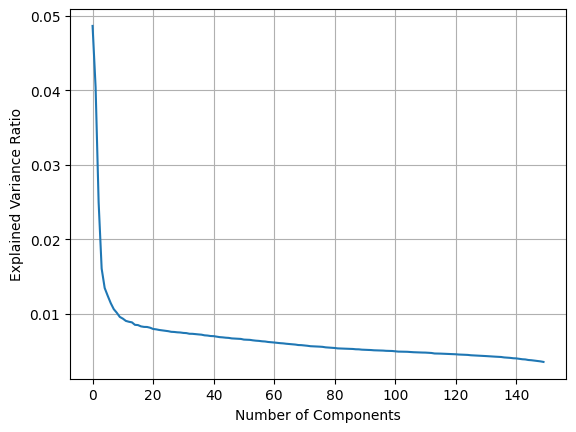

In [ ]:
pca = PCA().fit(X_train_padded)
plt.plot(pca.explained_variance_ratio_)
plt.xlabel('Number of Components')
plt.ylabel('Explained Variance Ratio')
plt.grid()
plt.show()


### KMeans Models

In [ ]:
def article_kmeans(articles, embedding_extractor, num_clusters=4, batch_size=1000, pca_components=15):
    num_batches = len(articles) // batch_size
    if len(articles) % batch_size != 0:
        num_batches += 1

    all_embeddings = []
    for i in range(num_batches):
        start_idx = i * batch_size
        end_idx = min((i + 1) * batch_size, len(articles))
        batch_articles = articles[start_idx:end_idx]
        batch_embeddings = embedding_extractor.predict(batch_articles)
        all_embeddings.append(batch_embeddings)

    X = np.concatenate(all_embeddings, axis=0)

    # Apply PCA if specified
    if pca_components is not None:
        pca = PCA(n_components=pca_components, random_state=42)
        X = pca.fit_transform(X)

    kmeans = MiniBatchKMeans(n_clusters=num_clusters, random_state=42)
    kmeans.fit(X)

    # Get the cluster labels for each review
    cluster_labels = kmeans.labels_

    # get inertia for compactness; lower inertia indicates tighter clusters
    cluster_inertia = kmeans.inertia_

    return cluster_labels, cluster_inertia

64 Clusters without PCA

In [ ]:
clustered_articles_64, clustered_inertia_64 = article_kmeans(articles=X_train_padded,
                                       embedding_extractor=embedding_extractor,
                                       num_clusters=64,
                                       batch_size=1000,
                                       pca_components=None)

In [ ]:
# check it ran properly and 64 clusters were created
print("64 Clusters")
print(set(clustered_articles_64))
print("Cluster Inertia:", clustered_inertia_64)

64 Clusters
{0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63}
Cluster Inertia: 65.04057312011719


31 Clusters without PCA

In [ ]:
clustered_articles_31, clustered_inertia_31 = article_kmeans(articles=X_train_padded,
                                       embedding_extractor=embedding_extractor,
                                       num_clusters=31,
                                       batch_size=1000,
                                       pca_components=None)

In [ ]:
# check it ran properly and 31 clusters were created
print(set(clustered_articles_31))
print("Cluster Inertia:", clustered_inertia_31)

{0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30}
Cluster Inertia: 68.34228515625


8 Clusters without PCA

In [ ]:
clustered_articles_8_nopca, clustered_inertia_8_nopca = article_kmeans(articles=X_train_padded,
                                       embedding_extractor=embedding_extractor,
                                       num_clusters=8,
                                       batch_size=1000,
                                       pca_components=None)

In [ ]:
# check it ran properly and 8 clusters were created
print("8 Clusters without PCA")
print(set(clustered_articles_8_nopca))
print("Cluster Inertia:", clusterec:\Users\kyle.wong\Documents\GraphBOM\BOM_PoC.ipynbd_inertia_8_nopca)

8 Clusters without PCA
{0, 1, 2, 3, 4, 5, 6, 7}
Cluster Inertia: 82.16416931152344


8 Clusters with PCA

In [ ]:
clustered_articles_8, clustered_inertia_8 = article_kmeans(articles=X_train_padded,
                                       embedding_extractor=embedding_extractor,
                                       num_clusters=8,
                                       batch_size=1000,
                                       pca_components=8)

In [ ]:
# check it ran properly and 8 clusters were created
print("4 Clusters without PCA")
print(set(clustered_articles_8))
print("Cluster Inertia:", clustered_inertia_8)

4 Clusters without PCA
{0, 1, 2, 3, 4, 5, 6, 7}
Cluster Inertia: 28.144550323486328


4 Clusters without PCA

In [ ]:
clustered_articles_4_nopca, clustered_inertia_4_nopca = article_kmeans(articles=X_train_padded,
                                       embedding_extractor=embedding_extractor,
                                       num_clusters=4,
                                       batch_size=1000,
                                       pca_components=None)

In [ ]:
# check it ran properly and 4 clusters were created
print("4 Clusters without PCA")
print(set(clustered_articles_4_nopca))
print("Cluster Inertia:", clustered_inertia_4_nopca)

4 Clusters without PCA
{0, 1, 2, 3}
Cluster Inertia: 113.94789123535156


4 Clusters with PCA

In [ ]:
clustered_articles_4, clustered_inertia_4 = article_kmeans(articles=X_train_padded,
                                       embedding_extractor=embedding_extractor,
                                       num_clusters=4,
                                       batch_size=1000,
                                       pca_components=8)

In [ ]:
# check it ran properly and 4 clusters were created
print("4 Clusters with PCA")
print(set(clustered_articles_4))
print("Cluster Inertia:", clustered_inertia_4)

4 Clusters with PCA
{0, 1, 2, 3}
Cluster Inertia: 59.9711799621582


### Visualize

In [ ]:
 def visualize_clusters(embeddings, cluster_labels):
    # Apply t-SNE to reduce the dimensionality of embeddings to 2 dimensions
    tsne = TSNE(n_components=2, random_state=42)
    embeddings_2d = tsne.fit_transform(embeddings)

    plt.figure(figsize=(10, 8))
    unique_labels = set(cluster_labels)
    colors = plt.cm.get_cmap('tab10', len(unique_labels))
    for label in unique_labels:
        indices = cluster_labels == label
        plt.scatter(embeddings_2d[indices, 0], embeddings_2d[indices, 1], color=colors(label), label=f'Cluster {label}')

    plt.title('t-SNE Visualization of Clusters')
    plt.xlabel('Dimension 1')
    plt.ylabel('Dimension 2')
    plt.legend()
    plt.show()

64 Clusters

<ipython-input-38-71682b3d3785>:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = plt.cm.get_cmap('tab10', len(unique_labels))


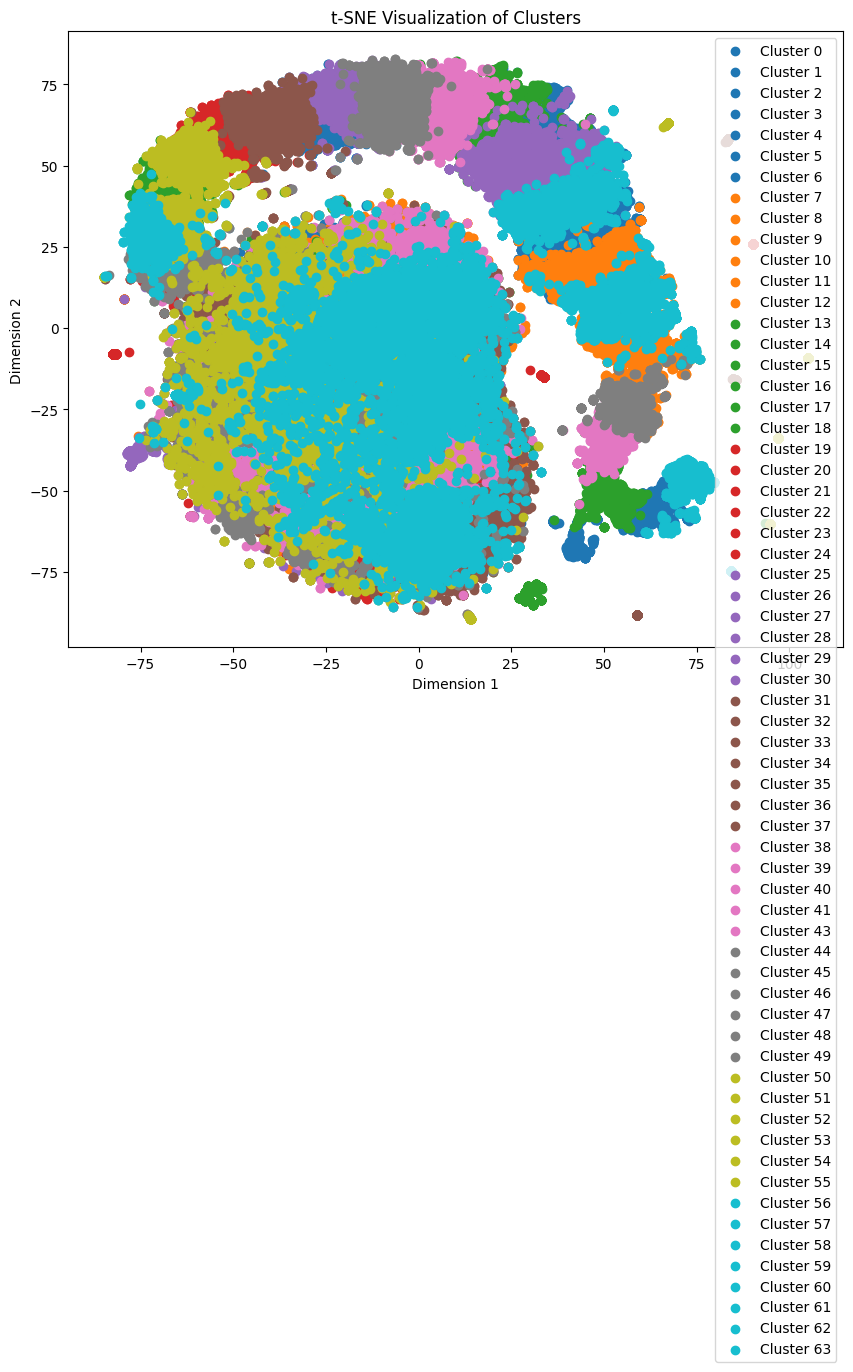

In [ ]:
visualize_clusters(X_train_embeddings, clustered_articles_64)

31 Clusters

<ipython-input-48-71682b3d3785>:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = plt.cm.get_cmap('tab10', len(unique_labels))


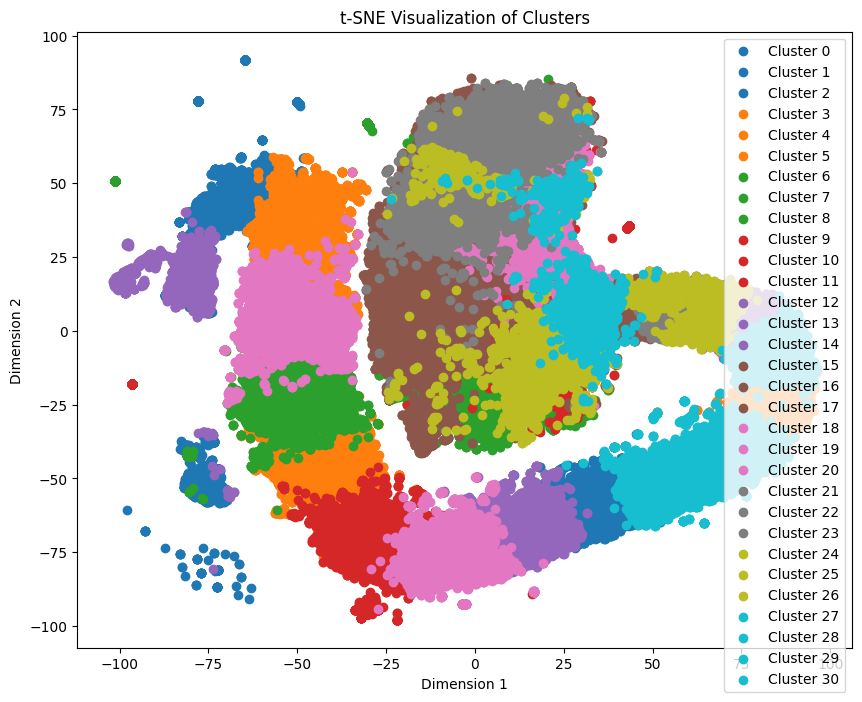

In [ ]:
visualize_clusters(X_train_embeddings, clustered_articles_31)

8 Clusters without PCA

<ipython-input-38-71682b3d3785>:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = plt.cm.get_cmap('tab10', len(unique_labels))


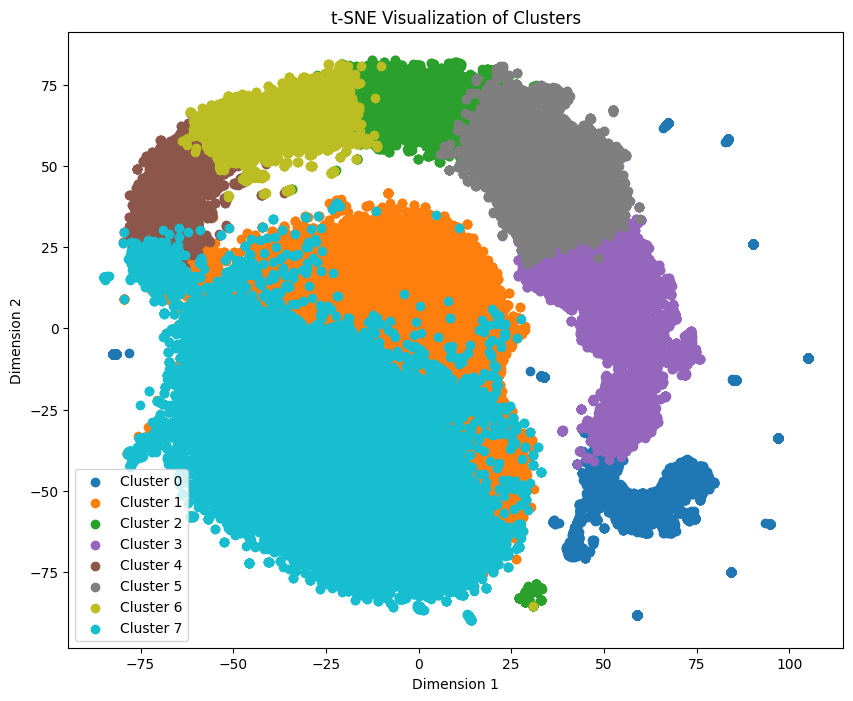

In [ ]:
visualize_clusters(X_train_embeddings, clustered_articles_8_nopca)

8 Clusters with PCA

<ipython-input-38-71682b3d3785>:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = plt.cm.get_cmap('tab10', len(unique_labels))


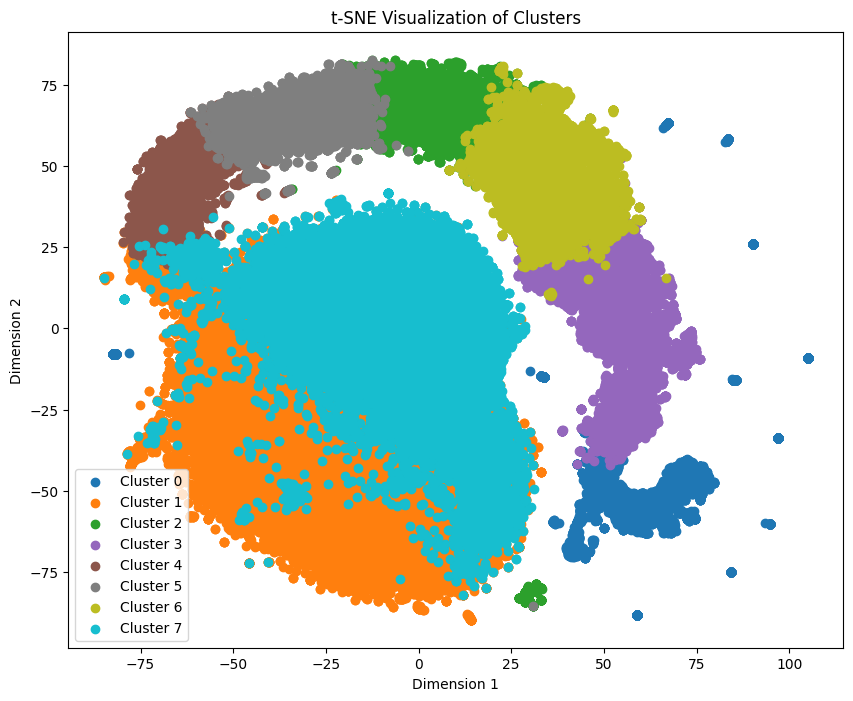

In [ ]:
visualize_clusters(X_train_embeddings, clustered_articles_8)

4 Clusters without PCA

<ipython-input-38-71682b3d3785>:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = plt.cm.get_cmap('tab10', len(unique_labels))


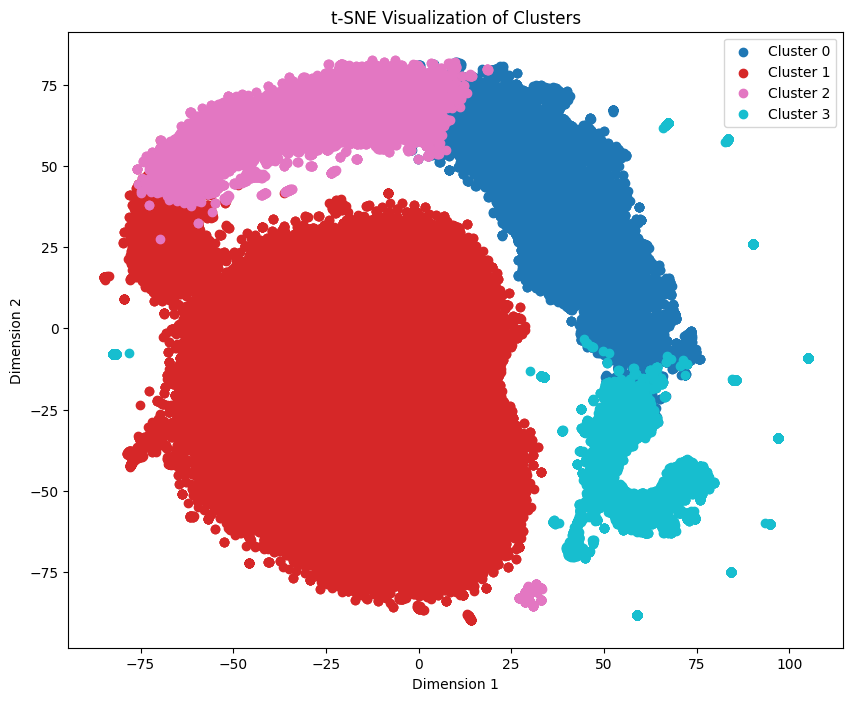

In [ ]:
visualize_clusters(X_train_embeddings, clustered_articles_4_nopca)

4 Clusters with PCA

<ipython-input-48-71682b3d3785>:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = plt.cm.get_cmap('tab10', len(unique_labels))


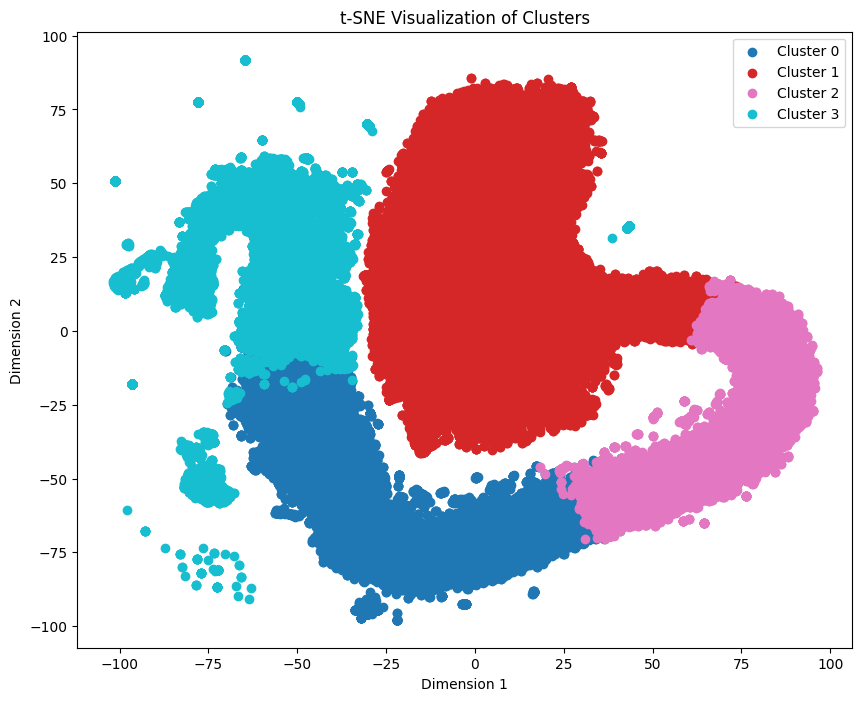

In [ ]:
visualize_clusters(X_train_embeddings, clustered_articles_4)

### Kmeans Results

Add kmeans groupings back to initial df to compare to actuals

In [ ]:
X_train['kmeans_group'] = clustered_articles_4

In [ ]:
X_train['kmeans_group'].value_counts()

kmeans_group
1    47547
2    19056
0    14865
3    10140
Name: count, dtype: int64

In [ ]:
X_train['main_categories'].value_counts()

main_categories
Culture                43952
Geography              28727
STEM                   12192
History_and_Society     6737
Name: count, dtype: int64

In [ ]:
X_train[X_train['kmeans_group']==0][['intro_text','main_categories','categories','kmeans_group']][:10]

,intro_text,main_categories,categories,kmeans_group
49282,Schaufling is a municipality in the district o...,1,Geography.Regions.Europe.Europe*,0
41145,Red Kiss French : Rouge Baiser is a 1985 Fre...,0,Culture.Media.Media*,0
66513,"The Gostynia is a river of southern Poland , a...",1,Geography.Regions.Europe.Eastern_Europe,0
31193,The desert yellow bat Scotoecus pallidus is ...,3,STEM.Biology,0
29939,Cloacibacillus is a Gramnegative and anaerobic...,3,STEM.Biology,0
60650,Error: Unable to fetch the article. Response c...,1,Geography.Regions.Oceania,0
10390,"Harry K. Cull March 2, 1911 February 2, 2000 ...",0,Culture.Biography.Biography*,0
54665,Error: Unable to fetch the article. Response c...,1,Geography.Regions.Asia.Asia*,0
87334,SalkylLcysteine sulfoxide lyase may refer to:,0,Culture.Food_and_drink,0
26547,Ksenia Borisovna Tikhonenko Russian : ; bo...,0,Culture.Sports,0


In [ ]:
X_train[X_train['kmeans_group']==1][['intro_text','main_categories','categories','kmeans_group']][:10]

,intro_text,main_categories,categories,kmeans_group
56281,Whiteout were a British rock group from Greeno...,0,Culture.Media.Music,1
27588,"Blanfords bat Hesperoptenus blanfordi , also ...",3,STEM.Biology,1
62671,The Mont Cenis was an international express tr...,2,History_and_Society.Transportation,1
90557,An antimetric electrical network is an electri...,3,STEM.Technology,1
59069,"Slip Gates , 1 also known as Stang Stoops , 1 ...",1,Geography.Regions.Europe.Northern_Europe,1
81138,Niha Arabic : Arabic pronunciation: nia is ...,1,Geography.Regions.Asia.West_Asia,1
19105,William Cowan Fotheringham 1899 1981 was a Sc...,0,Culture.Sports,1
12839,Jillian Anne Ellis born 6 September 1966 is an...,0,Culture.Biography.Biography*,1
61878,Fairfield is a suburb to the northeast of cent...,1,Geography.Regions.Oceania,1
7281,Second Lieutenant Bruce DigbyWorsley was a Wor...,0,Culture.Biography.Biography*,1


In [ ]:
X_train[X_train['kmeans_group']==2][['intro_text','main_categories','categories','kmeans_group']][:10]

,intro_text,main_categories,categories,kmeans_group
25499,Richard Simmons 1737 1802 was an English cric...,0,Culture.Sports,2
84943,"The Longhua Temple , also known as the Lon Wa ...",1,Geography.Regions.Asia.Southeast_Asia,2
14743,"Kazunori Yamanoi , Yamanoi Kazunori , born ...",0,Culture.Biography.Biography*,2
20189,Nugroho Fatchur Rochman born 8 September 1996 ...,0,Culture.Sports,2
9292,The Womens National Champions are the National...,0,Culture.Biography.Biography*,2
74455,HorseheadMarbella is an historic summer house ...,0,Culture.Visual_arts.Architecture,2
84330,Joinville Island is the largest island of the ...,1,Geography.Geographical,2
87953,Peltier Channel 6452S 6332W 64.867S 63.533...,3,STEM.Earth_and_environment,2
84749,Sayyidina Husain Secondary School Malay : Sek...,1,Geography.Regions.Asia.Southeast_Asia,2
22867,The 1923 Maine Black Bears football team was a...,0,Culture.Sports,2


In [ ]:
X_train[X_train['kmeans_group']==3][['intro_text','main_categories','categories','kmeans_group']][:10]

,intro_text,main_categories,categories,kmeans_group
30402,The fulvus roundleaf bat or fulvus leafnosed b...,3,STEM.Biology,3
25565,The Bowling Green Barons were a baseball team ...,0,Culture.Sports,3
44556,A choke ring antenna is a directional antenna ...,3,STEM.STEM*,3
34457,Saint Joseph Hospital was a Catholic operated ...,1,Geography.Regions.Americas.North_America,3
66417,"The Peasant Party of Ukraine Ukrainian : ,...",1,Geography.Regions.Europe.Eastern_Europe,3
13883,Joachim Heinrich Wilhelm Wagener 16 July 1782 ...,0,Culture.Biography.Biography*,3
65313,Sardar Muhammad Chaudhry 19372001 practised la...,1,Geography.Regions.Asia.South_Asia,3
68518,The Bijankhan corpus Persian : is a tagged...,0,Culture.Linguistics,3
28366,"Stylidium hispidum , the white butterfly trigg...",3,STEM.Biology,3
25599,"Stephen Hoar born May 28, 1982 in Oshawa , Ont...",0,Culture.Sports,3


How do our groupings compare to main category grouping?
---



In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
accuracy = accuracy_score(y_train, clustered_articles)
precision = precision_score(y_train, clustered_articles, average='macro')
recall = recall_score(y_train, clustered_articles, average='macro')
f1 = f1_score(y_train, clustered_articles, average='macro')
print(accuracy)
print(precision)
print(recall)
print(f1)


0.2413579797685758
0.19705789876177104
0.19782993030347099
0.18933630408256233


KMeans conclusion - The KMeans approach seems to be kind of working based on visual inspection of the articles. For instance, cluster 3 captured lots of the articles where we couldn't scrape anything. But, the methodology our Kmeans model took to cluster this data was not the same methodology used by Wikipedia's categories. Maybe it's clustering a different way...

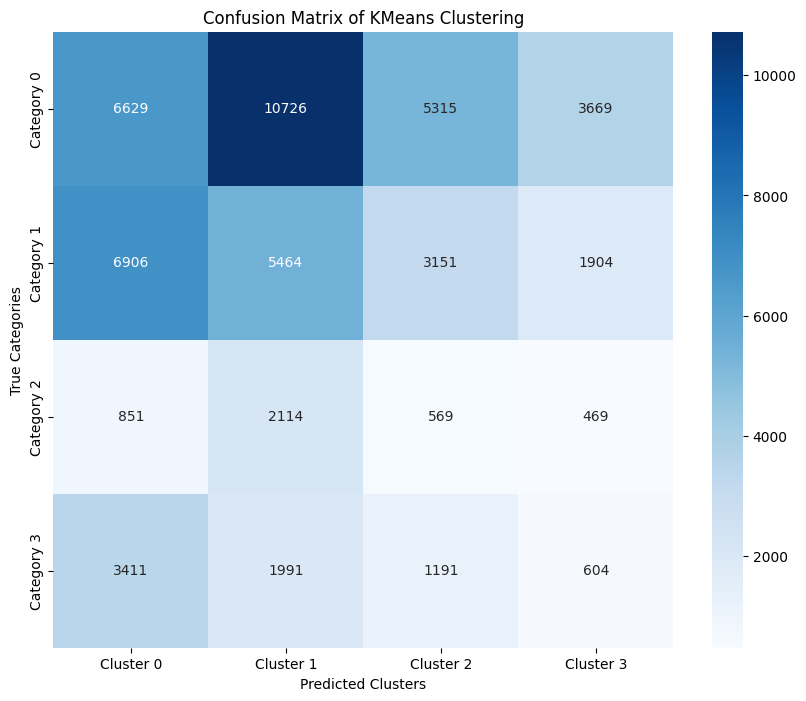

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

conf_matrix = confusion_matrix(y_train, clustered_articles)

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Cluster 0', 'Cluster 1', 'Cluster 2', 'Cluster 3'], yticklabels=['Category 0', 'Category 1', 'Category 2', 'Category 3'])
plt.xlabel('Predicted Clusters')
plt.ylabel('True Categories')
plt.title('Confusion Matrix of KMeans Clustering')
plt.show()

- confusion matrix just to see how the categories labels and predictions align.
- category 0 (culture) is most confused with cluster 1
- category 1 (geography) is most confused with cluster 0
- category 2 (history_society) is most confused with cluster 1
- category 3 (stem) is most confused with cluster 0

seems to confuse articles as cluster 1 the most and then cluster 0

In [ ]:
!pip install nltk
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
from collections import Counter
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def decode_article(token_ids):
    return ' '.join([reverse_index.get(id, "#") for id in token_ids if id > 3])

def count_words(token_ids):
    words = Counter()
    text = decode_article(token_ids)
    words.update([word for word in text.lower().split() if word not in stop_words and word.isalpha()])
    return words

cluster_texts = X_train.groupby('kmeans_group')['intro_text_tokenized'].apply(lambda token_lists: [token for sublist in token_lists for token in sublist])
cluster_word_counts = {cluster: count_words(texts).most_common(15) for cluster, texts in cluster_texts.items()}

category_texts = X_train.groupby('main_categories')['intro_text_tokenized'].apply(lambda token_lists: [token for sublist in token_lists for token in sublist])
category_word_counts = {category: count_words(texts).most_common(15) for category, texts in category_texts.items()}

def print_common_words(common_words):
    for group, words in common_words.items():
        print(f"Group {group}:")
        for word, count in words:
            print(f"  {word}: {count}")
        print("\n")

print("Common words by K-means cluster:")
print_common_words(cluster_word_counts)

print("Common words by original category:")
print_common_words(category_word_counts)

Common words by K-means cluster:
Group 0:
  unable: 6507
  north: 6464
  help: 5749
  football: 1989
  south: 1661
  km: 1615
  film: 1491
  century: 1385
  little: 1355
  building: 1027
  wikipedia: 1025
  even: 996
  april: 965
  league: 866
  different: 862


Group 1:
  article: 16849
  first: 13972
  expanding: 13535
  also: 13454
  wikipedia: 12637
  stub: 12241
  born: 11932
  one: 10534
  new: 9398
  two: 8975
  school: 8500
  known: 7609
  university: 7527
  american: 7215
  since: 7162


Group 2:
  help: 7500
  football: 2217
  also: 2171
  league: 2040
  article: 1978
  film: 1960
  first: 1927
  wikipedia: 1868
  stub: 1765
  years: 1613
  time: 1555
  building: 1464
  year: 1388
  state: 1373
  expanding: 1366


Group 3:
  help: 3682
  first: 3009
  also: 2956
  article: 2866
  expanding: 2673
  stub: 2328
  wikipedia: 2212
  one: 2089
  new: 1732
  born: 1662
  two: 1553
  years: 1529
  state: 1529
  time: 1513
  university: 1452


Common words by original category:
Group 

## User Inputs

In [ ]:
def get_user_input(prompt):
    user_input = input(prompt)
    return user_input

input_article = get_user_input("Paste an article here: ")

KeyboardInterrupt: Interrupted by user

In [ ]:
def article_cleaner(text):
  desired_text = r'[^a-zA-Z0-9\s.,!?;:]+'
  return re.sub(desired_text, '', text)

input_article = article_cleaner(input_article)

tokenized_article = tokenizer.texts_to_sequences(input_article)

padded_article = pad_data(tokenized_article, max_length=300)

article_embeddings = embedding_extractor.predict(padded_article)





### Visualize clustering of embeddings

In [ ]:
from sklearn.manifold import TSNE
def plot_2d_embeddings_matplotlib(embeddings, reverse_index, id_start=1, count=100, use_tsne=True):
    """
    Plot 2D embeddings with t-SNE reduction.
    """
    # Make sure we don't attempt to plot more embeddings than we have
    count = min(count, embeddings.shape[0] - id_start)

    if use_tsne:
        # Reduce dimensionality with t-SNE to avoid dimensionality issues
        tsne = TSNE(n_components=2, random_state=42)
        reduced_embeddings = tsne.fit_transform(embeddings[id_start:id_start+count])
    else:
        reduced_embeddings = embeddings[id_start:id_start+count]

    # Getting words from reverse index for labeling
    tokens = [reverse_index.get(i + id_start, '?') for i in range(count)]

    # Plot stuff
    plt.figure(figsize=(12, 12))
    for i, token in enumerate(tokens):
        x, y = reduced_embeddings[i, 0], reduced_embeddings[i, 1]
        plt.scatter(x, y)
        plt.annotate(token, xy=(x, y), xytext=(5, 2), textcoords='offset points', ha='right', va='bottom')

    plt.xlabel('Embedding Dimension 1')
    plt.ylabel('Embedding Dimension 2')
    plt.title('2D Token Embeddings Visualization')
    plt.show()

plot_2d_embeddings_matplotlib(X_train_embeddings, reverse_index, id_start=500, count=100)

In [ ]:
def visualize_clusters(embeddings, cluster_labels):
    # Apply t-SNE to reduce the dimensionality of embeddings to 2 dimensions
    tsne = TSNE(n_components=2, random_state=42)
    embeddings_2d = tsne.fit_transform(embeddings)

    plt.figure(figsize=(10, 8))
    unique_labels = set(cluster_labels)
    colors = plt.cm.get_cmap('tab10', len(unique_labels))
    for label in unique_labels:
        indices = cluster_labels == label
        plt.scatter(embeddings_2d[indices, 0], embeddings_2d[indices, 1], color=colors(label), label=f'Cluster {label}')

    plt.title('t-SNE Visualization of Clusters')
    plt.xlabel('Dimension 1')
    plt.ylabel('Dimension 2')
    plt.legend()
    plt.show()

visualize_clusters(X_train_padded, clustered_articles)

## Article Quality Neural Net

In [29]:
def build_embeddings_model(average_over_positions=True,
                           vocab_size=1000,
                           sequence_length=300,
                           embedding_dim=2):

  tf.keras.backend.clear_session()
  tf.random.set_seed(0)
  model = tf.keras.Sequential()
  model.add(tf.keras.layers.Embedding(
      input_dim=vocab_size,
      output_dim=embedding_dim,
      input_length=sequence_length)
  )

  if average_over_positions:
    model.add(tf.keras.layers.GlobalAveragePooling1D())
  else:
    model.add(tf.keras.layers.Flatten())
  model.add(tf.keras.layers.Dense(units=1, activation='relu'))
  model.add(tf.keras.layers.Dense(
      units=1,
      activation='sigmoid'
  ))

  model.compile(loss='binary_crossentropy',
                optimizer='adam',
                metrics=['accuracy'])

  return model

In [30]:
# Limit vocab

def limit_vocab(sequences, max_token_id, oov_id=3):
  reduced_sequences = np.copy(sequences)
  reduced_sequences[reduced_sequences >= max_token_id] = oov_id
  return reduced_sequences

# Reduce vocabulary to 5000 tokens.
Kag_X_train_red = limit_vocab(Kag_X_train_padded, max_token_id=500000)
Kag_X_test_red = limit_vocab(Kag_X_test_padded, max_token_id=500000)

In [31]:
def plot_history(history):
  plt.ylabel('Loss')
  plt.xlabel('Epoch')
  plt.xticks(range(0, len(history['loss'] + 1)))
  plt.plot(history['loss'], label="training", marker='o')
  plt.plot(history['val_loss'], label="validation", marker='o')
  plt.legend()
  plt.show()

Epoch 1/5
527/527 [==============================] - 71s 129ms/step - loss: 0.2210 - accuracy: 0.9748 - val_loss: 0.1112 - val_accuracy: 0.9738
Epoch 2/5
527/527 [==============================] - 25s 46ms/step - loss: 0.1066 - accuracy: 0.9748 - val_loss: 0.1085 - val_accuracy: 0.9738
Epoch 3/5
527/527 [==============================] - 15s 29ms/step - loss: 0.1034 - accuracy: 0.9748 - val_loss: 0.1063 - val_accuracy: 0.9738
Epoch 4/5
527/527 [==============================] - 12s 23ms/step - loss: 0.1005 - accuracy: 0.9748 - val_loss: 0.1042 - val_accuracy: 0.9738
Epoch 5/5
527/527 [==============================] - 8s 16ms/step - loss: 0.0977 - accuracy: 0.9748 - val_loss: 0.1023 - val_accuracy: 0.9738


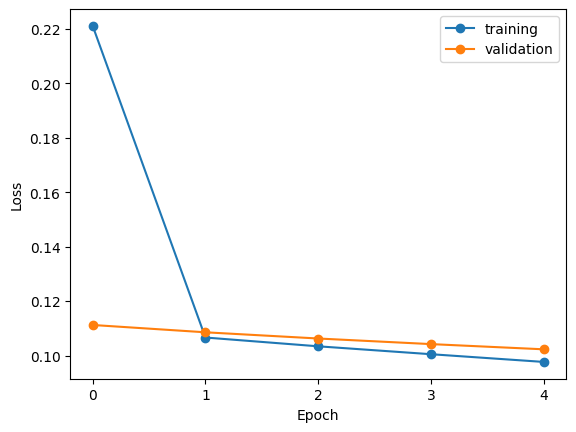

In [32]:
model = build_embeddings_model(average_over_positions=True,
                               vocab_size=1000,
                               sequence_length=150,
                               embedding_dim=64)
history = model.fit(
  x = Kag_X_train_red,
  y = Kag_Y_train,      # corresponding binary labels
  epochs=5,             # number of passes through the training data
  batch_size=64,        # mini-batch size
  validation_split=0.1, # use a fraction of the examples for validation
  verbose=1             # display some progress output during training
  )

history = pd.DataFrame(history.history)
plot_history(history)

Epoch 1/5
176/176 [==============================] - 29s 148ms/step - loss: 0.4952 - accuracy: 0.9754 - val_loss: 0.2311 - val_accuracy: 0.9656
Epoch 2/5
176/176 [==============================] - 17s 99ms/step - loss: 0.1352 - accuracy: 0.9754 - val_loss: 0.1391 - val_accuracy: 0.9656
Epoch 3/5
176/176 [==============================] - 12s 67ms/step - loss: 0.1063 - accuracy: 0.9754 - val_loss: 0.1391 - val_accuracy: 0.9656
Epoch 4/5
176/176 [==============================] - 10s 60ms/step - loss: 0.1042 - accuracy: 0.9754 - val_loss: 0.1384 - val_accuracy: 0.9656
Epoch 5/5
176/176 [==============================] - 9s 52ms/step - loss: 0.1028 - accuracy: 0.9754 - val_loss: 0.1378 - val_accuracy: 0.9656


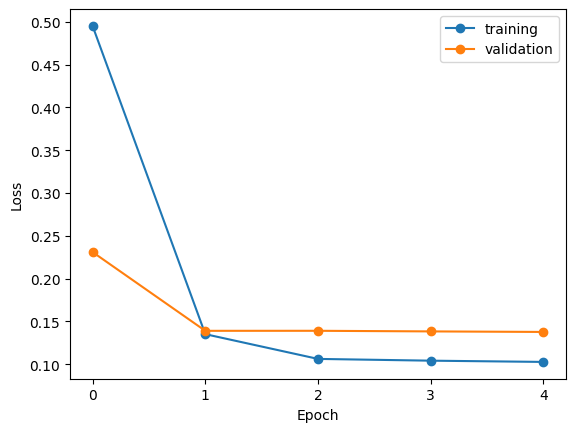

In [ ]:
model = build_embeddings_model(average_over_positions=True,
                               vocab_size=1000,
                               sequence_length=150,
                               embedding_dim=64)
history = model.fit(
  x = Kag_X_test_red,
  y = Kag_Y_test,      # corresponding binary labels
  epochs=5,             # number of passes through the training data
  batch_size=64,        # mini-batch size
  validation_split=0.1, # use a fraction of the examples for validation
  verbose=1             # display some progress output during training
  )

history = pd.DataFrame(history.history)
plot_history(history)

In [57]:
X_train_emb_df = pd.DataFrame(X_train_embeddings)
drop_indices = np.random.choice(X_train_emb_df.index, 41658, replace=False) # keep the number of rows in Figshare dataset equal to Kaggle dataset
X_train_emd_subset = X_train_emb_df.drop(drop_indices)

Epoch 1/5
703/703 [==============================] - 6s 6ms/step - loss: 0.5545 - accuracy: 0.9741 - val_loss: 0.4364 - val_accuracy: 0.9792
Epoch 2/5
703/703 [==============================] - 3s 4ms/step - loss: 0.3630 - accuracy: 0.9741 - val_loss: 0.2940 - val_accuracy: 0.9792
Epoch 3/5
703/703 [==============================] - 3s 4ms/step - loss: 0.2576 - accuracy: 0.9741 - val_loss: 0.2142 - val_accuracy: 0.9792
Epoch 4/5
703/703 [==============================] - 3s 4ms/step - loss: 0.1984 - accuracy: 0.9741 - val_loss: 0.1681 - val_accuracy: 0.9792
Epoch 5/5
703/703 [==============================] - 3s 5ms/step - loss: 0.1642 - accuracy: 0.9741 - val_loss: 0.1406 - val_accuracy: 0.9792


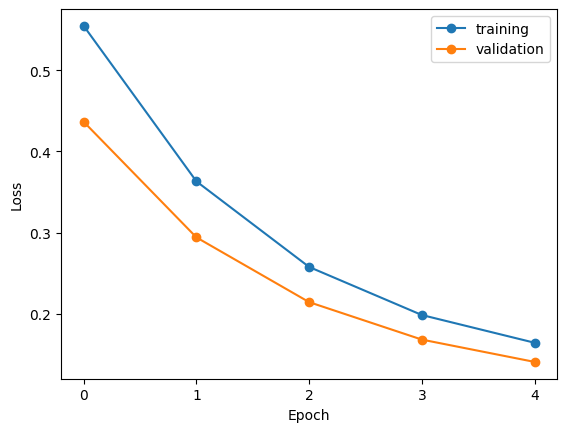

In [59]:
# Model on Figshare dataset, completely new data

model = build_embeddings_model(average_over_positions=True,
                               vocab_size=1000,
                               sequence_length=150,
                               embedding_dim=64)
history = model.fit(
  x = X_train_emd_subset,
  y = kaggle_df['Quality'],
  epochs=5,
  batch_size=64,
  validation_split=0.1,
  verbose=1
  )

history = pd.DataFrame(history.history)
plot_history(history)